In [2]:
import math
import numpy as np
import torch
import torch.nn as nn

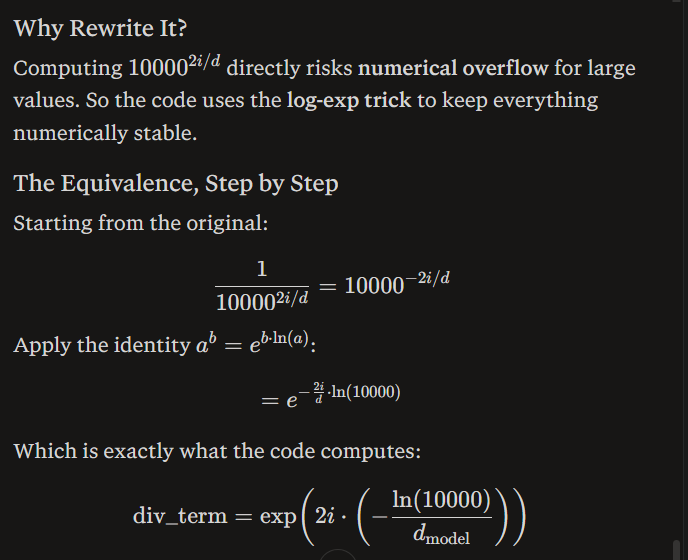

In [4]:
class PositionalEncoding(nn.Module):
    
    def __init__(self,d_model:int,dropout_prob:float, max_len : int=500):
        super().__init__()
        self.dropout=nn.Dropout(dropout_prob)
        self.register_buffer('positional_encodings',get_positional_encoding(d_model,max_len), False)

    def forward(self,x:torch.Tensor):
        pe=self.positional_encoding[:x.shape[0]].detach().requires_grad_(False)
        x=x+pe
        x=self.dropout(x)
        return x 
    
    
    

    
        
        
        
    




In [3]:
def get_positional_encoding(d_model:int,max_len:int = 5000):
        encodings = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        two_i=torch.arange(0, d_model, 2 , dtype=torch.float32)
        div_term=torch.exp(two_i* -(math.log(10000.0)/d_model))
        encodings[:,0::2]=torch.sin(position*div_term)
        encodings[:,1::2]=torch.cos(position*div_term)
        encodings=encodings.unsqueeze(1).requires_grad_(False)
        return encodings

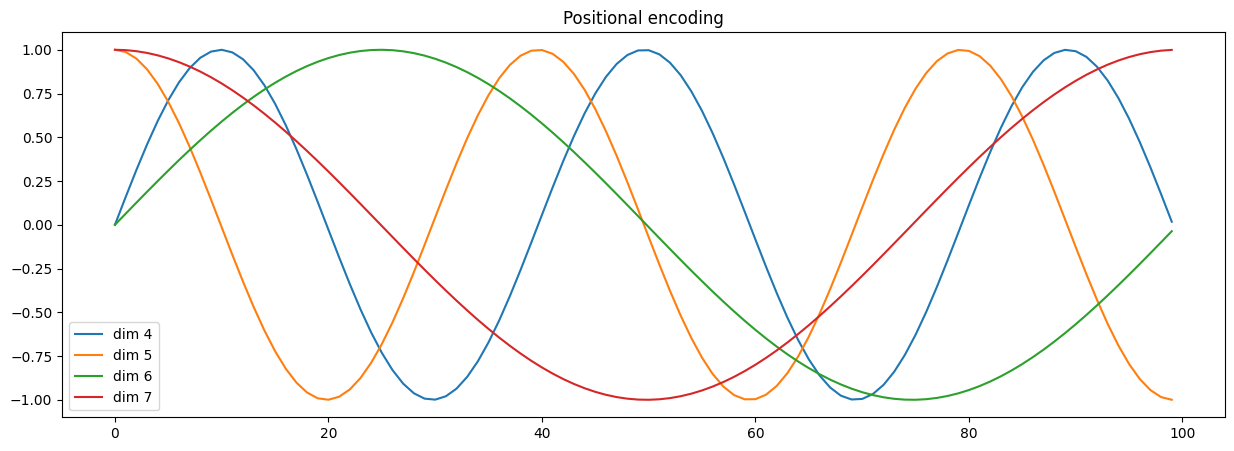

In [6]:
def _test_positional_encoding():
    import matplotlib.pyplot as plt

    plt.figure(figsize=(15,5))
    pe = get_positional_encoding(20,100)
    plt.plot(np.arange(100), pe[:, 0, 4:8].numpy())
    plt.legend(["dim %d" % p for p in [4, 5, 6, 7]])
    plt.title("Positional encoding")
    plt.show()


        
if __name__ == '__main__' :
    _test_positional_encoding()